# Итоговое сравнение моделей

## Сводная таблица результатов

Для финального сравнения объединим результаты лучшей табличной и лучшей текстовой модели в одну таблицу. Это позволяет напрямую сопоставить качество двух подходов на test-выборке.

На этом этапе формируется итоговая таблица с метриками и строится визуальное сравнение качества моделей.

In [78]:
best_tabular_summary = {
    "part": "tabular",
    "model": best_tabular_model_name,
    "test_accuracy": best_threshold_metrics_clean["test_accuracy"],
    "test_precision": best_threshold_metrics_clean["test_precision"],
    "test_recall": best_threshold_metrics_clean["test_recall"],
    "test_f1": best_threshold_metrics_clean["test_f1"],
    "test_roc_auc": best_threshold_metrics_clean["test_roc_auc"],
}

best_text_summary = {
    "part": "text",
    "model": best_text_model_name,
    "test_accuracy": best_text_metrics_clean["test_accuracy"],
    "test_precision": best_text_metrics_clean["test_precision"],
    "test_recall": best_text_metrics_clean["test_recall"],
    "test_f1": best_text_metrics_clean["test_f1"],
    "test_roc_auc": best_text_metrics_clean["test_roc_auc"],
}

final_model_summary = pd.DataFrame([
    best_tabular_summary,
    best_text_summary,
])

final_model_summary

,part,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,tabular,l2_dropout_mlp,0.708617,0.679630,0.813747,0.740666,0.820811
1,text,embedding_avg,0.759898,0.741284,0.895787,0.811245,0.843434


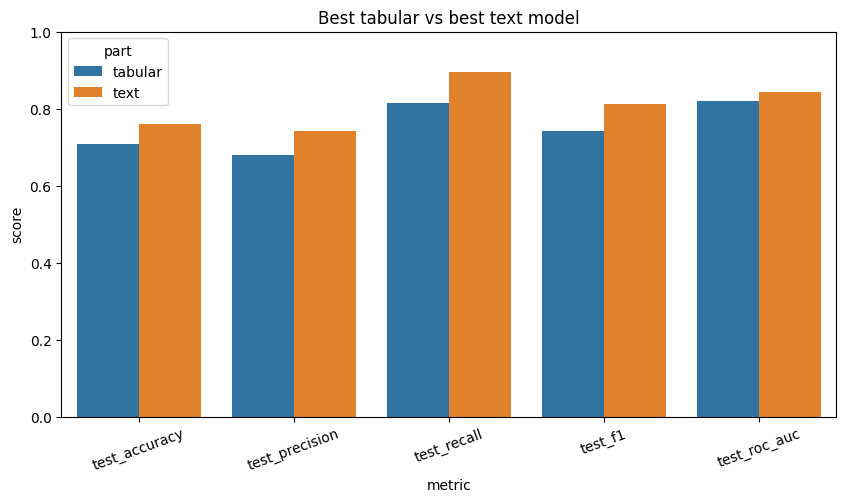

In [79]:
summary_long = final_model_summary.melt(
    id_vars=["part", "model"],
    value_vars=["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=summary_long, x="metric", y="score", hue="part")
plt.ylim(0, 1)
plt.title("Best tabular vs best text model")
plt.xticks(rotation=20)
plt.show()

## 21. Финальный вывод

В проекте были решены две связанные задачи для Airbnb Amsterdam: прогнозирование коммерческой эффективности объявления по табличным признакам и по текстам отзывов.

Табличная модель использует структурную информацию об объекте: цену, район, тип жилья, вместимость, характеристики хоста и другие признаки. Текстовая модель использует отзывы гостей, то есть информацию о реальном пользовательском опыте.

По итоговым метрикам текстовая модель `embedding_avg` показала более высокое качество, чем лучшая табличная модель `l2_dropout_mlp`: у неё выше ROC-AUC, F1 и recall на тестовой выборке. Это может означать, что отзывы гостей содержат сильный сигнал о привлекательности и потенциальной успешности объявления.

При этом табличная модель также остаётся полезной, потому что она объясняет коммерческую эффективность через структурные характеристики объекта. В практическом применении эти два подхода можно использовать вместе: табличные признаки помогают оценить свойства объявления, а текстовые признаки добавляют информацию о восприятии объекта гостями.

Все модели были обучены на train/validation/test split, сравнены по нескольким метрикам, а лучшие модели, метрики и MLflow-логи сохранены как артефакты проекта.